
**CSE475 Machine Learning Course**



In [1]:
# --- Shared setup: recreates the state from the original Lab 1 notebook ---
import os, time, random, gc, copy
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count() if device.type == "cuda" else 0

raw_train = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True)
raw_test  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)
class_names = raw_train.classes

N_TRAIN, N_VAL, N_TEST = 10000, 2000, 2000
g = torch.Generator().manual_seed(SEED)
train_perm = torch.randperm(len(raw_train), generator=g).tolist()
train_idx  = train_perm[:N_TRAIN]
val_idx    = train_perm[N_TRAIN:N_TRAIN + N_VAL]
test_perm  = torch.randperm(len(raw_test), generator=torch.Generator().manual_seed(0)).tolist()
test_idx   = test_perm[:N_TEST]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class IndexedDataset(Dataset):
    def __init__(self, base_ds, indices, transform):
        self.base = base_ds
        self.indices = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.base[self.indices[i]]
        return self.transform(img), label

train_ds = IndexedDataset(raw_train, train_idx, train_tf)
val_ds   = IndexedDataset(raw_train, val_idx,   eval_tf)
test_ds  = IndexedDataset(raw_test,  test_idx,  eval_tf)

BASE_BATCH = 64
BATCH = BASE_BATCH * max(1, n_gpus)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128,   shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=128,   shuffle=False, num_workers=2, pin_memory=True)

def unwrap(m):
    return m.module if isinstance(m, (nn.DataParallel, nn.parallel.DistributedDataParallel)) else m

def evaluate(model, loader, criterion, device, desc="Eval"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            bs = x.size(0)
            total_loss += loss.item() * bs
            correct += (out.argmax(1) == y).sum().item()
            total += bs
            pbar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")
    return total_loss / total, correct / total

def train_one_epoch(model, loader, opt, crit, device, epoch_num, total_epochs):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch_num:2d}/{total_epochs}", leave=False, dynamic_ncols=True)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        bs = x.size(0)
        total_loss += loss.item() * bs
        correct += (out.argmax(1) == y).sum().item()
        total += bs
        pbar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")
    return total_loss / total, correct / total

def build_model(pretrained=True, arch="mobilenet_v2"):
    if arch == "mobilenet_v2":
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        m = models.mobilenet_v2(weights=weights)
        m.classifier[1] = nn.Linear(m.last_channel, len(class_names))
    elif arch == "resnet18":
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        m = models.resnet18(weights=weights)
        m.fc = nn.Linear(m.fc.in_features, len(class_names))
    else:
        raise ValueError(arch)
    return m

def maybe_wrap(m):
    m = m.to(device)
    if n_gpus > 1:
        m = nn.DataParallel(m)
    return m

def run_training(model, train_loader, val_loader, epochs, lr=1e-4, ckpt_dir=None,
                  save_every=3, criterion=None, tag=""):
    criterion = criterion or nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    if ckpt_dir:
        os.makedirs(ckpt_dir, exist_ok=True)
        best_path = os.path.join(ckpt_dir, "best.pt")
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_acc, best_epoch = 0.0, -1
    epoch_times = []
    for ep in range(epochs):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device, ep + 1, epochs)
        vl, va = evaluate(model, val_loader, criterion, device, desc=f"Val {tag} {ep+1:2d}/{epochs}")
        dt = time.time() - t0
        epoch_times.append(dt)
        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta);   val_accs.append(va)
        if ckpt_dir and va > best_val_acc:
            best_val_acc, best_epoch = va, ep + 1
            torch.save({
                "epoch": ep + 1, "model_state_dict": unwrap(model).state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": va, "val_loss": vl, "classes": class_names,
            }, best_path)
        if ckpt_dir and (ep + 1) % save_every == 0:
            snap_path = os.path.join(ckpt_dir, f"epoch_{ep+1:02d}.pt")
            torch.save({
                "epoch": ep + 1, "model_state_dict": unwrap(model).state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": va, "val_loss": vl, "classes": class_names,
            }, snap_path)
        print(f"[{tag}] Epoch {ep+1:2d}/{epochs} | train loss {tl:.4f} acc {ta:.4f} | "
              f"val loss {vl:.4f} acc {va:.4f} | {dt:.1f}s")
    return {
        "train_losses": train_losses, "val_losses": val_losses,
        "train_accs": train_accs, "val_accs": val_accs,
        "best_val_acc": best_val_acc, "best_epoch": best_epoch,
        "epoch_times": epoch_times, "optimizer": optimizer,
    }

criterion = nn.CrossEntropyLoss()
EPOCHS = 10
CKPT_DIR = "./checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
BEST_PATH = os.path.join(CKPT_DIR, "best.pt")

print("Setup complete.")
print("Device:", device, "| GPUs:", n_gpus)
print(f"Train/Val/Test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

100%|██████████| 170M/170M [23:44<00:00, 120kB/s]  


Setup complete.
Device: cuda | GPUs: 2
Train/Val/Test sizes: 10000/2000/2000


## Exercise 1 — No Pretraining Baseline

Re-run training with `weights=None` (randomly initialized backbone) and compare final validation
accuracy against the pretrained run. The gap between the two shows what ImageNet pretraining buys you.


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 118MB/s] 


Epoch  1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val pretrained  1/10:   0%|          | 0/16 [00:00<?, ?it/s]

[pretrained] Epoch  1/10 | train loss 1.0781 acc 0.6519 | val loss 0.5093 acc 0.8435 | 30.9s


...

Val scratch  9/10:   0%|          | 0/16 [00:00<?, ?it/s]

[scratch] Epoch  9/10 | train loss 1.4789 acc 0.4494 | val loss 1.4521 acc 0.4745 | 89.2s


Epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val scratch 10/10:   0%|          | 0/16 [00:00<?, ?it/s]

[scratch] Epoch 10/10 | train loss 1.4509 acc 0.4665 | val loss 1.4045 acc 0.4795 | 29.9s

Best val acc — pretrained: 0.9210 (epoch 7)
Best val acc — scratch   : 0.4795 (epoch 10)
Pretraining gap          : +0.4415


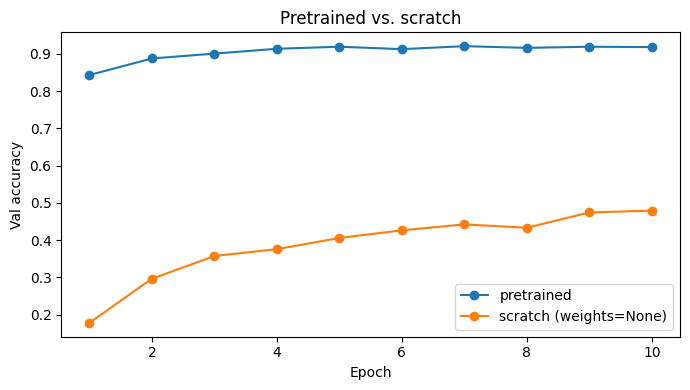

In [2]:
# --- Ex 1: No-pretraining baseline vs. pretrained ---
model_pretrained = maybe_wrap(build_model(pretrained=True))
res_pretrained = run_training(model_pretrained, train_loader, val_loader, EPOCHS,
                               ckpt_dir="./checkpoints_pretrained", tag="pretrained")

model_scratch = maybe_wrap(build_model(pretrained=False))
res_scratch = run_training(model_scratch, train_loader, val_loader, EPOCHS,
                            ckpt_dir="./checkpoints_scratch", tag="scratch")

print(f"\nBest val acc — pretrained: {res_pretrained['best_val_acc']:.4f} "
      f"(epoch {res_pretrained['best_epoch']})")
print(f"Best val acc — scratch   : {res_scratch['best_val_acc']:.4f} "
      f"(epoch {res_scratch['best_epoch']})")
print(f"Pretraining gap          : {res_pretrained['best_val_acc'] - res_scratch['best_val_acc']:+.4f}")

plt.figure(figsize=(7,4))
plt.plot(range(1, EPOCHS+1), res_pretrained["val_accs"], "o-", label="pretrained")
plt.plot(range(1, EPOCHS+1), res_scratch["val_accs"], "o-", label="scratch (weights=None)")
plt.xlabel("Epoch"); plt.ylabel("Val accuracy"); plt.title("Pretrained vs. scratch")
plt.legend(); plt.tight_layout(); plt.show()

## Exercise 2 — Freeze the Backbone

Freeze every parameter except the final classifier (`model.classifier`), so only the new head trains.
Compare training time per epoch and final accuracy against full fine-tuning.


In [3]:
# --- Ex 2: Freeze backbone, train classifier head only ---
model_frozen = build_model(pretrained=True)
for name, p in model_frozen.named_parameters():
    p.requires_grad = ("classifier" in name)

n_trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_frozen.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.2f}%)")

model_frozen = maybe_wrap(model_frozen)
res_frozen = run_training(model_frozen, train_loader, val_loader, EPOCHS,
                           ckpt_dir="./checkpoints_frozen", tag="frozen")

avg_time_frozen = np.mean(res_frozen["epoch_times"])
avg_time_full = np.mean(res_pretrained["epoch_times"])  # from Exercise 1, full fine-tuning
print(f"\nAvg epoch time — frozen backbone : {avg_time_frozen:.1f}s")
print(f"Avg epoch time — full fine-tune  : {avg_time_full:.1f}s")
print(f"Best val acc   — frozen backbone : {res_frozen['best_val_acc']:.4f}")
print(f"Best val acc   — full fine-tune  : {res_pretrained['best_val_acc']:.4f}")

Trainable params: 12,810 / 2,236,682 (0.57%)


Epoch  1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val frozen  1/10:   0%|          | 0/16 [00:00<?, ?it/s]

[frozen] Epoch  1/10 | train loss 2.1580 acc 0.2311 | val loss 2.0041 acc 0.3805 | 77.5s


Epoch  2/10:   0%|          | 0/79 [00:00<?, ?it/s]

...

Val frozen  9/10:   0%|          | 0/16 [00:00<?, ?it/s]

[frozen] Epoch  9/10 | train loss 1.1936 acc 0.6310 | val loss 1.1617 acc 0.6570 | 27.2s


Epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val frozen 10/10:   0%|          | 0/16 [00:00<?, ?it/s]

[frozen] Epoch 10/10 | train loss 1.1560 acc 0.6482 | val loss 1.1137 acc 0.6705 | 27.2s

Avg epoch time — frozen backbone : 45.6s
Avg epoch time — full fine-tune  : 48.3s
Best val acc   — frozen backbone : 0.6705
Best val acc   — full fine-tune  : 0.9210


## Exercise 3 — Augmentation Ablation

Drop `RandomHorizontalFlip` and `ColorJitter` from the training transform (keep resize/rotation/
normalize) and measure the change in validation accuracy versus the full-augmentation run.


In [4]:
# --- Ex 3: Augmentation ablation ---
train_tf_noaug = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
train_ds_noaug = IndexedDataset(raw_train, train_idx, train_tf_noaug)
train_loader_noaug = DataLoader(train_ds_noaug, batch_size=BATCH, shuffle=True,
                                 num_workers=2, pin_memory=True)

model_noaug = maybe_wrap(build_model(pretrained=True))
res_noaug = run_training(model_noaug, train_loader_noaug, val_loader, EPOCHS,
                          ckpt_dir="./checkpoints_noaug", tag="no-flip-jitter")

print(f"\nBest val acc — full augmentation : {res_pretrained['best_val_acc']:.4f}")
print(f"Best val acc — no flip/jitter     : {res_noaug['best_val_acc']:.4f}")
print(f"Change                            : {res_noaug['best_val_acc'] - res_pretrained['best_val_acc']:+.4f}")

Epoch  1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val no-flip-jitter  1/10:   0%|          | 0/16 [00:00<?, ?it/s]

[no-flip-jitter] Epoch  1/10 | train loss 1.0931 acc 0.6461 | val loss 0.5047 acc 0.8395 | 87.8s


Epoch  2/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val no-flip-jitter  2/10:   0%|          | 0/16 [00:00<?, ?it/s]

...

Val no-flip-jitter  9/10:   0%|          | 0/16 [00:00<?, ?it/s]

[no-flip-jitter] Epoch  9/10 | train loss 0.0572 acc 0.9849 | val loss 0.2510 acc 0.9175 | 97.5s


Epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val no-flip-jitter 10/10:   0%|          | 0/16 [00:00<?, ?it/s]

[no-flip-jitter] Epoch 10/10 | train loss 0.0556 acc 0.9841 | val loss 0.2561 acc 0.9150 | 27.6s

Best val acc — full augmentation : 0.9210
Best val acc — no flip/jitter     : 0.9190
Change                            : -0.0020


## Exercise 4 — Confusion Analysis

Identify which two classes the trained model confuses most often, using the test-set confusion
matrix, and judge whether that confusion is semantically reasonable (e.g. cat vs. dog) or not.


Test:   0%|          | 0/16 [00:00<?, ?it/s]

Most confused pair: true='dog' predicted as 'cat' (19 times)

Top 5 confused class pairs:
  cat          <-> dog           35 misclassifications combined
  automobile   <-> truck         18 misclassifications combined
  bird         <-> frog          13 misclassifications combined
  deer         <-> horse         12 misclassifications combined
  airplane     <-> ship          12 misclassifications combined


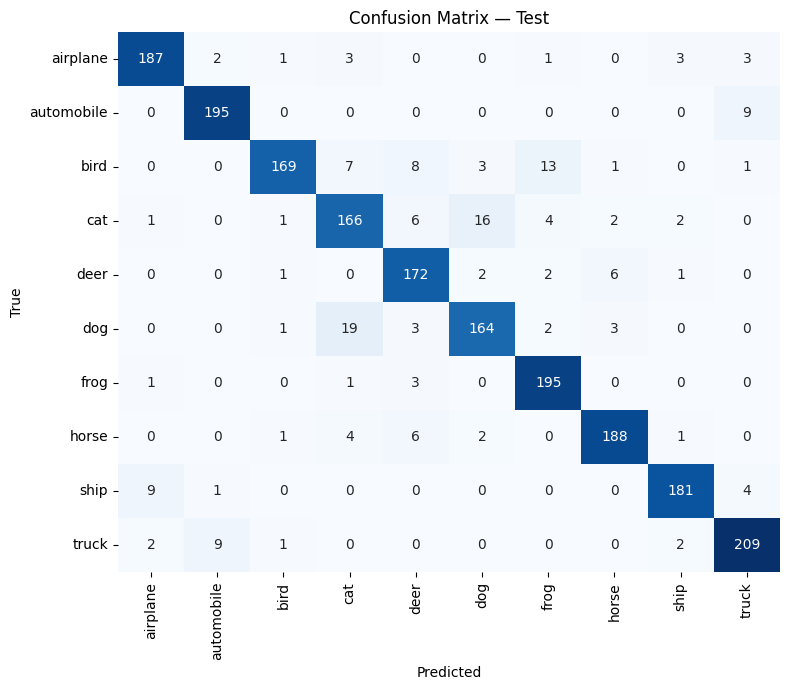

In [5]:
# --- Ex 4: Confusion analysis on the pretrained model from Exercise 1 ---
fresh_model = build_model(pretrained=False)
ckpt = torch.load(os.path.join("./checkpoints_pretrained", "best.pt"), map_location=device)
fresh_model.load_state_dict(ckpt["model_state_dict"])
fresh_model = fresh_model.to(device)
fresh_model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Test", leave=False):
        x = x.to(device)
        out = fresh_model(x)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())

cm = confusion_matrix(all_targets, all_preds)
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

i, j = np.unravel_index(cm_offdiag.argmax(), cm_offdiag.shape)
print(f"Most confused pair: true='{class_names[i]}' predicted as '{class_names[j]}' "
      f"({cm_offdiag[i, j]} times)")

# Top 5 confused pairs (both directions combined)
sym = cm_offdiag + cm_offdiag.T
pairs = []
for a in range(len(class_names)):
    for b in range(a+1, len(class_names)):
        pairs.append((sym[a, b], class_names[a], class_names[b]))
pairs.sort(reverse=True)
print("\nTop 5 confused class pairs:")
for count, a, b in pairs[:5]:
    print(f"  {a:<12s} <-> {b:<12s}  {count} misclassifications combined")

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix — Test")
plt.tight_layout(); plt.show()

## Exercise 5 — Different Backbone (ResNet18)

Swap MobileNetV2 for ResNet18 and compare parameter count, average epoch time, and final
validation accuracy.


In [6]:
# --- Ex 5: ResNet18 vs MobileNetV2 ---
model_resnet = build_model(pretrained=True, arch="resnet18")
n_params_resnet = sum(p.numel() for p in model_resnet.parameters())
n_params_mobilenet = sum(p.numel() for p in unwrap(model_pretrained).parameters())

model_resnet = maybe_wrap(model_resnet)
res_resnet = run_training(model_resnet, train_loader, val_loader, EPOCHS,
                           ckpt_dir="./checkpoints_resnet18", tag="resnet18")

print(f"\n{'Model':<15s}{'Params':>15s}{'Avg epoch (s)':>16s}{'Best val acc':>14s}")
print(f"{'MobileNetV2':<15s}{n_params_mobilenet:>15,}{np.mean(res_pretrained['epoch_times']):>16.1f}"
      f"{res_pretrained['best_val_acc']:>14.4f}")
print(f"{'ResNet18':<15s}{n_params_resnet:>15,}{np.mean(res_resnet['epoch_times']):>16.1f}"
      f"{res_resnet['best_val_acc']:>14.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Epoch  1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val resnet18  1/10:   0%|          | 0/16 [00:00<?, ?it/s]

[resnet18] Epoch  1/10 | train loss 0.8100 acc 0.7366 | val loss 0.3614 acc 0.8855 | 29.2s


...

Val resnet18  9/10:   0%|          | 0/16 [00:00<?, ?it/s]

[resnet18] Epoch  9/10 | train loss 0.0450 acc 0.9877 | val loss 0.2272 acc 0.9275 | 28.8s


Epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val resnet18 10/10:   0%|          | 0/16 [00:00<?, ?it/s]

[resnet18] Epoch 10/10 | train loss 0.0443 acc 0.9885 | val loss 0.2292 acc 0.9260 | 28.7s

Model                   Params   Avg epoch (s)  Best val acc
MobileNetV2          2,236,682            48.3        0.9210
ResNet18            11,181,642            36.8        0.9310


## Exercise 6 — Resume From a Snapshot

Load `epoch_03.pt`'s `model_state_dict` **and** `optimizer_state_dict` into a fresh model and
optimizer, continue training for 5 more epochs, and plot the resumed validation curve against the
original run's curve.


Resumed from epoch 3  (val_acc at save time: 0.9010)


Epoch  1/5:   0%|          | 0/79 [00:00<?, ?it/s]

Val resumed 1:   0%|          | 0/16 [00:00<?, ?it/s]

Resumed epoch 1/5 | train acc 0.9220 | val acc 0.9110


Epoch  2/5:   0%|          | 0/79 [00:00<?, ?it/s]

...

Val resumed 4:   0%|          | 0/16 [00:00<?, ?it/s]

Resumed epoch 4/5 | train acc 0.9583 | val acc 0.9185


Epoch  5/5:   0%|          | 0/79 [00:00<?, ?it/s]

Val resumed 5:   0%|          | 0/16 [00:00<?, ?it/s]

Resumed epoch 5/5 | train acc 0.9676 | val acc 0.9120


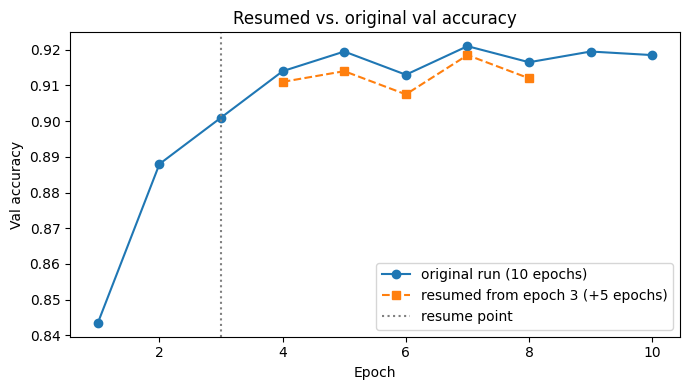

In [7]:
# --- Ex 6: Resume training from epoch_03.pt checkpoint ---
snap_path = os.path.join("./checkpoints_pretrained", "epoch_03.pt")
assert os.path.exists(snap_path), "Run Exercise 1 first so epoch_03.pt exists."
ckpt3 = torch.load(snap_path, map_location=device)

resumed_model = build_model(pretrained=False)
resumed_model.load_state_dict(ckpt3["model_state_dict"])
resumed_model = maybe_wrap(resumed_model)

resumed_optimizer = torch.optim.Adam(resumed_model.parameters(), lr=1e-4)
resumed_optimizer.load_state_dict(ckpt3["optimizer_state_dict"])

print(f"Resumed from epoch {ckpt3['epoch']}  (val_acc at save time: {ckpt3['val_acc']:.4f})")

RESUME_EPOCHS = 5
resumed_val_accs = []
for ep in range(RESUME_EPOCHS):
    tl, ta = train_one_epoch(resumed_model, train_loader, resumed_optimizer, criterion,
                              device, ep + 1, RESUME_EPOCHS)
    vl, va = evaluate(resumed_model, val_loader, criterion, device, desc=f"Val resumed {ep+1}")
    resumed_val_accs.append(va)
    print(f"Resumed epoch {ep+1}/{RESUME_EPOCHS} | train acc {ta:.4f} | val acc {va:.4f}")

# Plot: original epochs 1-10 val curve vs. resumed epochs 4-8 (continuing from epoch 3)
plt.figure(figsize=(7,4))
plt.plot(range(1, EPOCHS+1), res_pretrained["val_accs"], "o-", label="original run (10 epochs)")
resumed_x = range(ckpt3["epoch"] + 1, ckpt3["epoch"] + 1 + RESUME_EPOCHS)
plt.plot(list(resumed_x), resumed_val_accs, "s--", label="resumed from epoch 3 (+5 epochs)")
plt.axvline(ckpt3["epoch"], color="gray", linestyle=":", label="resume point")
plt.xlabel("Epoch"); plt.ylabel("Val accuracy"); plt.title("Resumed vs. original val accuracy")
plt.legend(); plt.tight_layout(); plt.show()

## Exercise 7 — Best vs. Last Checkpoint

Load the latest periodic snapshot (e.g. `epoch_09.pt`) instead of `best.pt` and compare test
performance. They differ whenever validation accuracy peaked before the final epoch (i.e. the
model started overfitting late in training).


In [8]:
# --- Ex 7: Compare best.pt vs. the latest periodic snapshot ---
ckpt_dir = "./checkpoints_pretrained"
best_ckpt = torch.load(os.path.join(ckpt_dir, "best.pt"), map_location=device)

snap_files = sorted([f for f in os.listdir(ckpt_dir) if f.startswith("epoch_")])
latest_snap_file = snap_files[-1]
latest_ckpt = torch.load(os.path.join(ckpt_dir, latest_snap_file), map_location=device)

def load_and_eval(ckpt, label):
    m = build_model(pretrained=False).to(device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    vl, va = evaluate(m, val_loader, criterion, device, desc=f"Eval {label}")
    tl, ta = evaluate(m, test_loader, criterion, device, desc=f"Test {label}")
    print(f"{label:<20s} saved_epoch={ckpt['epoch']:>2d}  val_acc={va:.4f}  test_acc={ta:.4f}")
    return va, ta

print(f"Latest periodic snapshot: {latest_snap_file}\n")
best_val_acc_ckpt, best_test_acc = load_and_eval(best_ckpt, "best.pt")
last_val_acc_ckpt, last_test_acc = load_and_eval(latest_ckpt, latest_snap_file)

print(f"\nbest.pt was saved at epoch {best_ckpt['epoch']}; "
      f"training ran for {EPOCHS} epochs.")
if best_ckpt["epoch"] < EPOCHS:
    print("They differ because validation accuracy peaked before the final epoch — "
          "the model likely started overfitting afterward, so best.pt captured the "
          "highest-generalization checkpoint instead of the most-trained one.")
else:
    print("They coincide here because the best validation accuracy happened to occur "
          "on the final epoch of training.")

Latest periodic snapshot: epoch_09.pt



Eval best.pt:   0%|          | 0/16 [00:00<?, ?it/s]

Test best.pt:   0%|          | 0/16 [00:00<?, ?it/s]

best.pt              saved_epoch= 7  val_acc=0.9210  test_acc=0.9130


Eval epoch_09.pt:   0%|          | 0/16 [00:00<?, ?it/s]

Test epoch_09.pt:   0%|          | 0/16 [00:00<?, ?it/s]

epoch_09.pt          saved_epoch= 9  val_acc=0.9195  test_acc=0.9075

best.pt was saved at epoch 7; training ran for 10 epochs.
They differ because validation accuracy peaked before the final epoch — the model likely started overfitting afterward, so best.pt captured the highest-generalization checkpoint instead of the most-trained one.


## Exercise 8 — Strip the Optimizer

Re-save `best.pt` with only `model_state_dict` and `classes` (no optimizer state) and compare
file size. Useful when shipping a model for inference-only deployment.


In [9]:
# --- Ex 8: Strip optimizer state from checkpoint, compare file sizes ---
best_path_full = os.path.join("./checkpoints_pretrained", "best.pt")
best_path_stripped = os.path.join("./checkpoints_pretrained", "best_stripped.pt")

full_ckpt = torch.load(best_path_full, map_location=device)
stripped_ckpt = {
    "model_state_dict": full_ckpt["model_state_dict"],
    "classes": full_ckpt["classes"],
}
torch.save(stripped_ckpt, best_path_stripped)

size_full = os.path.getsize(best_path_full) / 1e6
size_stripped = os.path.getsize(best_path_stripped) / 1e6

print(f"Full checkpoint (model + optimizer): {size_full:.2f} MB")
print(f"Stripped checkpoint (model only)   : {size_stripped:.2f} MB")
print(f"Size reduction                     : {size_full - size_stripped:.2f} MB "
      f"({100*(1 - size_stripped/size_full):.1f}% smaller)")
print("\nAdam optimizer state roughly doubles/triples checkpoint size because it stores "
      "per-parameter momentum and variance buffers in addition to the weights themselves — "
      "irrelevant for inference-only deployment.")

Full checkpoint (model + optimizer): 27.18 MB
Stripped checkpoint (model only)   : 9.19 MB
Size reduction                     : 17.99 MB (66.2% smaller)

Adam optimizer state roughly doubles/triples checkpoint size because it stores per-parameter momentum and variance buffers in addition to the weights themselves — irrelevant for inference-only deployment.


## Exercise 9 — Wrong Normalization

Replace `IMAGENET_MEAN`/`IMAGENET_STD` with `[0,0,0]`/`[1,1,1]` (i.e. no normalization — raw
[0,1] pixel values fed to the model) and measure how much accuracy is lost.


In [10]:
# --- Ex 9: No normalization ablation ---
ZERO_MEAN = [0.0, 0.0, 0.0]
UNIT_STD  = [1.0, 1.0, 1.0]

train_tf_nonorm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(ZERO_MEAN, UNIT_STD),
])
eval_tf_nonorm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(ZERO_MEAN, UNIT_STD),
])

train_ds_nonorm = IndexedDataset(raw_train, train_idx, train_tf_nonorm)
val_ds_nonorm   = IndexedDataset(raw_train, val_idx,   eval_tf_nonorm)

train_loader_nonorm = DataLoader(train_ds_nonorm, batch_size=BATCH, shuffle=True,
                                  num_workers=2, pin_memory=True)
val_loader_nonorm   = DataLoader(val_ds_nonorm,   batch_size=128,   shuffle=False,
                                  num_workers=2, pin_memory=True)

model_nonorm = maybe_wrap(build_model(pretrained=True))
res_nonorm = run_training(model_nonorm, train_loader_nonorm, val_loader_nonorm, EPOCHS,
                           ckpt_dir="./checkpoints_nonorm", tag="no-norm")

print(f"\nBest val acc — with ImageNet normalization : {res_pretrained['best_val_acc']:.4f}")
print(f"Best val acc — no normalization ([0,0,0]/[1,1,1]) : {res_nonorm['best_val_acc']:.4f}")
print(f"Accuracy lost : {res_pretrained['best_val_acc'] - res_nonorm['best_val_acc']:+.4f}")
print("\nWhy it hurts: the pretrained backbone's early conv filters were learned on inputs "
      "standardized to ImageNet's per-channel mean/std. Feeding raw [0,1] pixel values shifts "
      "the input distribution far from what those filters expect, so the pretrained features "
      "are less useful and the model effectively has to relearn more from scratch.")

Epoch  1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val no-norm  1/10:   0%|          | 0/16 [00:00<?, ?it/s]

[no-norm] Epoch  1/10 | train loss 1.0551 acc 0.6610 | val loss 0.4646 acc 0.8495 | 31.6s


Epoch  2/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val no-norm  2/10:   0%|          | 0/16 [00:00<?, ?it/s]

...

Val no-norm  9/10:   0%|          | 0/16 [00:00<?, ?it/s]

[no-norm] Epoch  9/10 | train loss 0.0915 acc 0.9704 | val loss 0.2539 acc 0.9200 | 33.0s


Epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Val no-norm 10/10:   0%|          | 0/16 [00:00<?, ?it/s]

[no-norm] Epoch 10/10 | train loss 0.0781 acc 0.9762 | val loss 0.2475 acc 0.9175 | 32.3s

Best val acc — with ImageNet normalization : 0.9210
Best val acc — no normalization ([0,0,0]/[1,1,1]) : 0.9200
Accuracy lost : +0.0010

Why it hurts: the pretrained backbone's early conv filters were learned on inputs standardized to ImageNet's per-channel mean/std. Feeding raw [0,1] pixel values shifts the input distribution far from what those filters expect, so the pretrained features are less useful and the model effectively has to relearn more from scratch.


## Exercise 10 — Multi-GPU Scaling

On a multi-GPU machine (e.g. Kaggle's T4×2), time one epoch with `n_gpus` forced to 1
(`model = unwrap(model)`) versus the natural multi-GPU `DataParallel` wrap, and check whether the
speedup is close to 2x.


In [11]:
# --- Ex 10: Time one epoch on 1 GPU vs. all visible GPUs ---
def time_one_epoch(force_single_gpu):
    m = build_model(pretrained=True).to(device)
    if not force_single_gpu and n_gpus > 1:
        m = nn.DataParallel(m)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4)
    crit = nn.CrossEntropyLoss()
    t0 = time.time()
    train_one_epoch(m, train_loader, opt, crit, device, 1, 1)
    dt = time.time() - t0
    del m, opt
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return dt

if n_gpus < 2:
    print(f"Only {n_gpus} GPU(s) visible in this environment — multi-GPU scaling test "
          "requires 2+ GPUs (e.g. Kaggle T4x2). Run this cell there to get real numbers.")
else:
    time_1gpu = time_one_epoch(force_single_gpu=True)
    time_2gpu = time_one_epoch(force_single_gpu=False)
    speedup = time_1gpu / time_2gpu
    print(f"1 GPU epoch time : {time_1gpu:.1f}s")
    print(f"{n_gpus} GPU epoch time : {time_2gpu:.1f}s")
    print(f"Speedup          : {speedup:.2f}x")
    print("\nDataParallel rarely hits a clean 2x: it replicates the model to each GPU every "
          "batch, splits the batch, gathers gradients back to GPU 0, and pays Python-side "
          "overhead for scattering/gathering — so real speedup is usually 1.3-1.7x on 2 GPUs, "
          "not 2x.")

Epoch  1/1:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch  1/1:   0%|          | 0/79 [00:00<?, ?it/s]

1 GPU epoch time : 40.9s
2 GPU epoch time : 27.0s
Speedup          : 1.52x

DataParallel rarely hits a clean 2x: it replicates the model to each GPU every batch, splits the batch, gathers gradients back to GPU 0, and pays Python-side overhead for scattering/gathering — so real speedup is usually 1.3-1.7x on 2 GPUs, not 2x.
